In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report, balanced_accuracy_score
from transformers import AutoFeatureExtractor, Wav2Vec2ForSequenceClassification, AutoConfig
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
import random

In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [3]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Wav2vec2_base

In [7]:
reset_seed(42)
wav2vec_base_path = 'wav2vec2_base'

wav2vec_base_processor = AutoFeatureExtractor.from_pretrained(wav2vec_base_path, padding=True)
wav2vec_base_config = AutoConfig.from_pretrained(wav2vec_base_path)

In [8]:
reset_seed(42)
emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3,
    'W' : 4
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger',
    4 : 'Wonder'
}

audios = []
sample_rates = []
emotions = []
labels = []
features = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = wav2vec_base_processor(audio_data, sampling_rate=sr, return_tensors="pt", padding="max_length", max_length=120000, truncation=True).input_values # Each sample is padded to the maxlen of 120000 (7.5 sec)
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                sample_rates.append(sr)
                emotion = char
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))

In [10]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]])  # Convert to PyTorch tensor if not already
        }

        return sample
    

Shemo = AudioDataSet(features, labels)


# Split the dataset into training and validation sets
trainset, valset = random_split(Shemo, [len(Shemo)-500, 500])


# Example of using DataLoader for batching
train_loader = DataLoader(trainset, batch_size=4, shuffle=True)
val_loader = DataLoader(valset, batch_size=4, shuffle=False)

In [11]:
len(features), len(features[0])

(2962, 120000)

# Train_Function

In [12]:
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs=40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): #each batch
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      training_loss.append(loss.data.item())
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {num_correct / num_examples : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it
        current_patience = 0
    else:
        current_patience += 1

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [13]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    output = model(inputs).logits
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss: .2f} | U_Accuracy: {u_acc : .2f} | W_Accuracy: {w_acc : .2f} | Precision: {precision : .2f} | Recall: {recall : .2f} | f1: {f1 : .2f}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

# Wav2vec_base

In [15]:
reset_seed(42)

wav2vec_base = Wav2Vec2ForSequenceClassification.from_pretrained(wav2vec_base_path)

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at wav2vec2_base and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'projector.weight', 'projector.bias', 'classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
reset_seed(42)
for param in wav2vec_base.parameters():
    param.requires_grad = False

for param in wav2vec_base.projector.parameters():
    param.requires_grad = True

for param in wav2vec_base.wav2vec2.encoder.pos_conv_embed.conv.parametrizations.parameters():
    param.requires_grad = True
    
wav2vec_base.classifier = torch.nn.Linear(256, 5) # Changing the head to fit our data and problem

In [21]:
wav2vec_base.to(device)

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)


In [22]:
reset_seed(42)
optimizer = torch.optim.Adam(wav2vec_base.parameters(), lr=0.001)

training_losses0, valid_losses0 = train(wav2vec_base, 'wav2vec_base_shemo', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

Epoch: 1 finished in 144.48 seconds, Training Loss:  1.03, Validation Loss: 0.79, Validation Accuracy:  0.75


Epoch: 2 finished in 143.46 seconds, Training Loss:  0.79, Validation Loss: 0.70, Validation Accuracy:  0.77


Epoch: 3 finished in 143.73 seconds, Training Loss:  0.68, Validation Loss: 0.67, Validation Accuracy:  0.79


Epoch: 4 finished in 144.63 seconds, Training Loss:  0.58, Validation Loss: 0.80, Validation Accuracy:  0.76


Epoch: 5 finished in 142.12 seconds, Training Loss:  0.52, Validation Loss: 0.77, Validation Accuracy:  0.77


...

Epoch: 36 finished in 144.52 seconds, Training Loss:  0.09, Validation Loss: 1.51, Validation Accuracy:  0.79


Epoch: 37 finished in 143.77 seconds, Training Loss:  0.05, Validation Loss: 1.37, Validation Accuracy:  0.81


Epoch: 38 finished in 144.23 seconds, Training Loss:  0.03, Validation Loss: 1.74, Validation Accuracy:  0.80


Epoch: 39 finished in 143.19 seconds, Training Loss:  0.07, Validation Loss: 1.36, Validation Accuracy:  0.81


Epoch: 40 finished in 143.47 seconds, Training Loss:  0.06, Validation Loss: 1.62, Validation Accuracy:  0.81
Each epoch took 142.71 seconds in average.


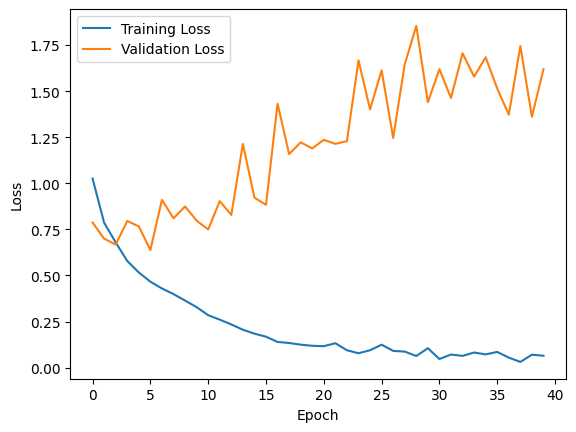

In [23]:
plt.plot(training_losses0, label='Training Loss')
plt.plot(valid_losses0, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

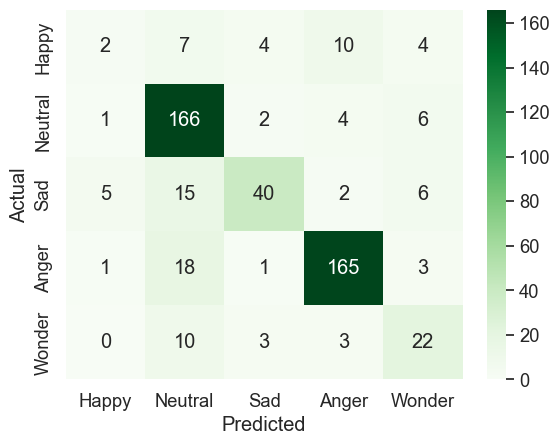

Testing finished with Loss:  0.64 | U_Accuracy:  0.61 | W_Accuracy:  0.79 | Precision:  0.77 | Recall:  0.79 | f1:  0.77
Accuracy per class:
Class 0: 0.07407407407407407
Class 1: 0.9273743016759777
Class 2: 0.5882352941176471
Class 3: 0.8776595744680851
Class 4: 0.5789473684210527


In [24]:
wav2vec_base.load_state_dict(torch.load('wav2vec_base_shemo.bin'))
test(wav2vec_base, torch.nn.CrossEntropyLoss(), val_loader)

# Wav2vec_large

In [25]:
reset_seed(42)

wav2vec_large_path = 'wav2vec2_large'
wav2vec_large = Wav2Vec2ForSequenceClassification.from_pretrained(wav2vec_large_path)

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at wav2vec2_large and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'projector.weight', 'projector.bias', 'classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
reset_seed(42)
for param in wav2vec_large.parameters():
    param.requires_grad = False

for param in wav2vec_large.projector.parameters():
    param.requires_grad = True

for param in wav2vec_large.wav2vec2.encoder.pos_conv_embed.conv.parametrizations.parameters():
    param.requires_grad = True
    
wav2vec_large.classifier = torch.nn.Linear(256, 5) # Changing the head to fit our data and problem

In [27]:
wav2vec_large.to(device)

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=1024, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)

In [28]:
reset_seed(42)
optimizer = torch.optim.Adam(wav2vec_large.parameters(), lr=0.001)

training_losses1, valid_losses1 = train(wav2vec_large, 'wav2vec_large_shemo', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

Epoch: 1 finished in 220.73 seconds, Training Loss:  1.12, Validation Loss: 1.87, Validation Accuracy:  0.51


Epoch: 2 finished in 220.75 seconds, Training Loss:  0.94, Validation Loss: 1.61, Validation Accuracy:  0.58


Epoch: 3 finished in 221.16 seconds, Training Loss:  0.87, Validation Loss: 2.05, Validation Accuracy:  0.59


Epoch: 4 finished in 218.79 seconds, Training Loss:  0.82, Validation Loss: 1.55, Validation Accuracy:  0.60


Epoch: 5 finished in 218.44 seconds, Training Loss:  0.77, Validation Loss: 1.04, Validation Accuracy:  0.70


...

Epoch: 36 finished in 216.63 seconds, Training Loss:  0.37, Validation Loss: 1.24, Validation Accuracy:  0.72


Epoch: 37 finished in 216.97 seconds, Training Loss:  0.34, Validation Loss: 1.56, Validation Accuracy:  0.72


Epoch: 38 finished in 216.55 seconds, Training Loss:  0.36, Validation Loss: 1.53, Validation Accuracy:  0.69


Epoch: 39 finished in 217.64 seconds, Training Loss:  0.34, Validation Loss: 1.33, Validation Accuracy:  0.75


Epoch: 40 finished in 217.77 seconds, Training Loss:  0.31, Validation Loss: 1.52, Validation Accuracy:  0.72
Each epoch took 220.18 seconds in average.


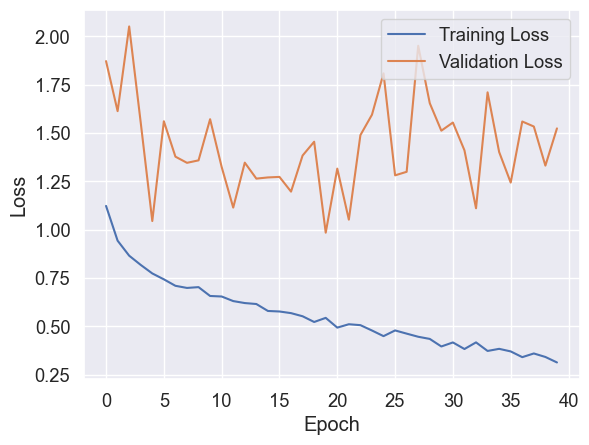

In [29]:
plt.plot(training_losses1, label='Training Loss')
plt.plot(valid_losses1, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

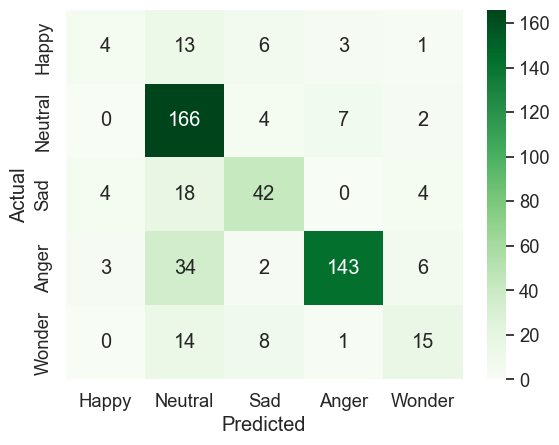

Testing finished with Loss:  0.98 | U_Accuracy:  0.57 | W_Accuracy:  0.74 | Precision:  0.74 | Recall:  0.74 | f1:  0.73
Accuracy per class:
Class 0: 0.14814814814814814
Class 1: 0.9273743016759777
Class 2: 0.6176470588235294
Class 3: 0.7606382978723404
Class 4: 0.39473684210526316


In [30]:
wav2vec_large.load_state_dict(torch.load('wav2vec_large_shemo.bin'))
test(wav2vec_large, torch.nn.CrossEntropyLoss(), val_loader)